In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Détectez les Bad Buzz grâce au Deep Learning

Dans ce blog, je vais vous présenter comment analyser et prédire les sentiments associés à des tweets via plusieurs approches utilisant les services de **Microsoft Azure**

### Objectif

Air Paradis veut un prototype d’un produit IA permettant de prédire le sentiment associé à un tweet.

### Missions

Préparer un prototype fonctionnel du modèle. Le modèle envoie un tweet et récupère la prédiction de sentiment. 

Préparer un support de présentation explicitant la méthodologie utilisée pour l’approche “modèle sur mesure avancé” (attention : audience non technique).

### Spécifications

Test de plusieurs approches:

**Approche “API sur étagère”** en utilisant l’API du service cognitif proposé par Microsoft Azure pour l’analyse de sentiment. Vu le coût de ce service, nous ne le testerons pas sur toute la base mais uniquement sur un ensemble de tests de quelques milliers d’exemples représentatifs de l’ensemble des données.


**Approche “Modèle sur mesure simple”** en utilisant le Concepteur / Designer d’un service Azure Machine Learning, interface graphique drag & drop, pour développer rapidement un modèle classique (ex : régression logistique) permettant de prédire le sentiment associé à un tweet.


**Approche “Modèle sur mesure avancé”** en utilisant le service Azure Machine Learning pour développer un modèle basé sur des réseaux de neurones profonds pour prédire le sentiment associé à un tweet. => C’est ce modèle qu'on pourra déployer et montrer à Air Paradis.
-- Nous allons essayer au moins deux word embeddings différents et à garder celui qui permet d’obtenir les meilleures performances. En complément, on regardera l’apport en performance d’un modèle BERT. Cela nous permettra de voir si nous devons investir dans ce type de modèle.



In [ ]:
# Importation des bibliothèques
import re
import pickle
import numpy as np
import pandas as pd

# plotting
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# nltk
from nltk.stem import WordNetLemmatizer

# sklearn
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report

## Importation de notre base de données et Preprocessing

In [ ]:
# Importation du dataset pour analyse
colonnes  = ["sentiment", "ids", "date", "flag", "user", "text"]
DATASET_ENCODING = "ISO-8859-1"

dataset = pd.read_csv('../input/data-sentiment/training.1600000.processed.noemoticon.csv',
                      encoding=DATASET_ENCODING , names=colonnes)

dataset.head()

In [ ]:
# Constitution de la variable étiquette
print("Les valeurs uniques de la variable 'sentiment' sont:")
pd.unique(dataset['sentiment'].values).tolist()

In [ ]:
# Retrait des colonnes non nécessaires
dataset = dataset[['sentiment','text']]
# Remplacement de la valeur  de la variable étiquette " sentiment" 4 par 1 
dataset['sentiment'] = dataset['sentiment'].replace(4,1)


In [ ]:
#Vérification si les classes sont équilibrées
from collections import Counter
from sklearn.datasets import make_classification
counter = Counter(dataset['sentiment'])
print("Composition de la variable sentiment:", counter)

In [ ]:
ax = dataset.groupby('sentiment').count().plot(kind='bar', title='Distribution des classe',
                                               legend=False)
ax.set_xticklabels(['Negative','Positive'], rotation=0)

### Preprocessing

Etapes du preprocessing:

Majuscules en minuscules
Remplacement des  URLs: Les liens commençant par "http", "https" ou "www" sont remplacés par "URL".

Remplacement des émoticones: Via l'utilisation d'un dico prédéfini contenant les émoticones et leurs définitions

Remplacement du nom des utilisateurs: @Usernames avec le mot "USER". 

Suppression des caractères non alphabétiques (à l'exception des chiffres)et remplacement par des espaces

Retrait des lettres qui se repètent et se suiventplus de 2 fois par leur occurence en 2 fois

Retrait des mots qui ont moins de 2 lettres

Retrait des Stopwords(exple: "the", "he", "have")

Lemmatization: utilisation de la racine des mots (exple: “Great” devient “Good”,"doing" devient "do")

In [ ]:
# Dico des émoticones
emojis = {':)': 'smile', ':-)': 'smile', ';d': 'wink', ':-E': 'vampire', ':(': 'sad', 
          ':-(': 'sad', ':-<': 'sad', ':P': 'raspberry', ':O': 'surprised',
          ':-@': 'shocked', ':@': 'shocked',':-$': 'confused', ':\\': 'annoyed', 
          ':#': 'mute', ':X': 'mute', ':^)': 'smile', ':-&': 'confused', '$_$': 'greedy',
          '@@': 'eyeroll', ':-!': 'confused', ':-D': 'smile', ':-0': 'yell', 'O.o': 'confused',
          '<(-_-)>': 'robot', 'd[-_-]b': 'dj', ":'-)": 'sadsmile', ';)': 'wink', 
          ';-)': 'wink', 'O:-)': 'angel','O*-)': 'angel','(:-D': 'gossip', '=^.^=': 'cat'}

## Les stopwords de la langue anglaise
stopwordlist = ['a', 'about', 'above', 'after', 'again', 'ain', 'all', 'am', 'an',
             'and','any','are', 'as', 'at', 'be', 'because', 'been', 'before',
             'being', 'below', 'between','both', 'by', 'can', 'd', 'did', 'do',
             'does', 'doing', 'down', 'during', 'each','few', 'for', 'from', 
             'further', 'had', 'has', 'have', 'having', 'he', 'her', 'here',
             'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', 'if', 'in',
             'into','is', 'it', 'its', 'itself', 'just', 'll', 'm', 'ma',
             'me', 'more', 'most','my', 'myself', 'now', 'o', 'of', 'on', 'once',
             'only', 'or', 'other', 'our', 'ours','ourselves', 'out', 'own', 're',
             's', 'same', 'she', "shes", 'should', "shouldve",'so', 'some', 'such',
             't', 'than', 'that', "thatll", 'the', 'their', 'theirs', 'them',
             'themselves', 'then', 'there', 'these', 'they', 'this', 'those', 
             'through', 'to', 'too','under', 'until', 'up', 've', 'very', 'was',
             'we', 'were', 'what', 'when', 'where','which','while', 'who', 'whom',
             'why', 'will', 'with', 'won', 'y', 'you', "youd","youll", "youre",
             "youve", 'your', 'yours', 'yourself', 'yourselves']

In [ ]:
def preprocess(textdata):
    processedText = []
    
    # Lemmatization et Stemming.
    wordLemm = WordNetLemmatizer()
    
    # regex patterns.
    urlPattern        = r"((http://)[^ ]*|(https://)[^ ]*|( www\.)[^ ]*)"
    userPattern       = '@[^\s]+'
    alphaPattern      = "[^a-zA-Z0-9]"
    sequencePattern   = r"(.)\1\1+"
    seqReplacePattern = r"\1\1"
    
    for tweet in textdata:
        tweet = tweet.lower()
        
        # Remplacement des URls par 'URL'
        tweet = re.sub(urlPattern,' URL',tweet)
        # Remplacement des emoti.
        for emoji in emojis.keys():
            tweet = tweet.replace(emoji, "EMOJI" + emojis[emoji])        
        # @USERNAME par 'USER'.
        tweet = re.sub(userPattern,' USER', tweet)        
        # Remplacement des caractères non-alphabétiques
        tweet = re.sub(alphaPattern, " ", tweet)
        # Remplacement des lettres qui se repètent consécutivement plus de 2 fois  par la lettre double
        tweet = re.sub(sequencePattern, seqReplacePattern, tweet)

        tweetwords = ''
        for word in tweet.split():
            # Vérification si le mot est un stopword
            #Si ce n'est pas le cas:
            if len(word)>1:
                # Lemmatizing the word.
                word = wordLemm.lemmatize(word)
                tweetwords += (word+' ')
            
        processedText.append(tweetwords)
        
    return processedText

In [ ]:
# Transformation des colonnes en listes
text= list(dataset['text']) 
sentiment = list(dataset['sentiment'])

In [ ]:
import time
t = time.time()
processedtext = preprocess(text)
print(f'Preprocessing effectué')
print(f'Temps utilisé: {round(time.time()-t)} secondes')

In [ ]:
#Construction du dataset avec les données textes nettoyées

tab = []
for text, pred in zip(processedtext, sentiment):
    tab.append((text,pred))
        
# Convert the list into a Pandas DataFrame.
Data_prepro = pd.DataFrame(tab, columns = ['prepro_text','sentiment'])
Data_prepro.head()

In [ ]:
# Mapping des classes 0 et 1 en positif et négatif
Data_prepro['sentiment'] = Data_prepro['sentiment'].replace(1,"Positif")
Data_prepro['sentiment'] = Data_prepro['sentiment'].replace(0,"Négatif")


## Analyse de nos sacs de mots 

###  Nuage de mots des tweets négatifs

In [ ]:
# Nuage de mots des tweets négatifs

data_neg = processedtext[:800000]
plt.figure(figsize = (20,20))
wc = WordCloud(max_words = 1000 , width = 1600 , height = 800,
               collocations=False).generate(" ".join(data_neg))
plt.imshow(wc)

###  Nuage de mots des tweets positifs

In [ ]:
data_pos = processedtext[800000:]
wc = WordCloud(max_words = 1000 , width = 1600 , height = 800,
              collocations=False).generate(" ".join(data_pos))
plt.figure(figsize = (20,20))
plt.imshow(wc)

Nous allons tout d'abord faire une première analyse de prédiction de sentiments via ce notebook sans utilisation service Azure. Cela nous permettra d'avoir une analyse sur l'ensemble de notre jeu de données.

En effet, avec le service Azure, nous ne pourrons utiliser qu'une partie de notre base car ce service est payant.

## Analyse de prédiction sans Azure

In [ ]:
### Séparation du jeu de données en jeu de test et jeu d'entraînement

X_train, X_test, y_train, y_test = train_test_split(processedtext, sentiment,
                                                    test_size = 0.3, random_state = 0)
print(f'Séparation du jeu de données effectuée.')

In [ ]:
### Vectorization TF-IDF
vectoriser = TfidfVectorizer(ngram_range=(1,2), max_features=500000)
vectoriser.fit(X_train)
print(f'Vectorization TF-IDF effectuée.')
print('Nombre de mots features: ', len(vectoriser.get_feature_names_out()))

In [ ]:
# Application à nos jeux d'entraînement et de test
X_train1 = vectoriser.transform(X_train)
X_test1  = vectoriser.transform(X_test)
print(f'Jeux de données transformés')

## Création des modèles et leur fonction d'évaluation

Nous utiliserons les algorithmes suivants:
Modèle naif bayesien Bernouilli,Modèle linéaire svm (séparateur à vaste marge) et le Modèle de regression logistique.

Avant cela, nous allons définir la fonction qui nous permettra d'évaluer nos modèles.

In [ ]:
def model_Evaluate(model):
    
    # Predict values for Test dataset
    y_pred = model.predict(X_test1)

    # Print the evaluation metrics for the dataset.
    print(classification_report(y_test, y_pred))
    
    # Compute and plot the Confusion matrix
    cf_matrix = confusion_matrix(y_test, y_pred)

    categories  = ['Negative','Positive']
    group_names = ['True Neg','False Pos', 'False Neg','True Pos']
    group_percentages = ['{0:.2%}'.format(value) for value in cf_matrix.flatten() / np.sum(cf_matrix)]

    labels = [f'{v1}\n{v2}' for v1, v2 in zip(group_names,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)

    sns.heatmap(cf_matrix, annot = labels, cmap = 'Blues',fmt = '',
                xticklabels = categories, yticklabels = categories)

    plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
    plt.ylabel("Actual values"   , fontdict = {'size':14}, labelpad = 10)
    plt.title ("Confusion Matrix", fontdict = {'size':18}, pad = 20)

### Modèle naif bayesion Bernouilli

In [ ]:
BNBmodel = BernoulliNB(alpha = 2)
BNBmodel.fit(X_train1, y_train)
model_Evaluate(BNBmodel)

### Modèle linéaire svm (séparateur à vaste marge)

In [ ]:
SVCmodel = LinearSVC()
SVCmodel.fit(X_train1, y_train)
model_Evaluate(SVCmodel)

### Modèle de regression logistique

In [ ]:
LRmodel = LogisticRegression(C = 2, max_iter = 1000, n_jobs=-1)
LRmodel.fit(X_train1, y_train)
model_Evaluate(LRmodel)

## Utilisation du modèle pour définir la fonction de prédiction

In [ ]:
def load_models():
    
    # Chargement du vectorizer
    file = open('vectoriser-ngram-(1,2).pickle', 'rb')
    vectoriser = pickle.load(file)
    file.close()
    # Chargement du modèle LR
    file = open('Sentiment-LRv1.pickle', 'rb')
    LRmodel = pickle.load(file)
    file.close()
    
    return vectoriser, LRmodel

def predict(vectoriser, model, text):
    # Prediction du sentiment
    textdata = vectoriser.transform(preprocess(text))
    sentiment = model.predict(textdata)
    
    # Création d'une liste de textes avec sentiment.
    data = []
    for text, pred in zip(text, sentiment):
        data.append((text,pred))
        
    # Convert the list into a Pandas DataFrame.
    df = pd.DataFrame(data, columns = ['text','sentiment'])
    df = df.replace([0,1], ["Negative","Positive"])
    return df

if __name__=="__main__":
    # Loading the models.
    #vectoriser, LRmodel = load_models()
    
    # Text to classify should be in a list.
    text = ["I'm so happy to share what I've learned with you on twitter",
            "Sad to see that we didn't learn from the history.",
            "Life is beautiful. Keep smiling!"]
    
    df = predict(vectoriser, LRmodel, text)
    print(df.head())


Ayant testé quelques modèles et construits quelques fonctions permettant d'attribuer un sentiment à un tweet. Nous allons utiliser les solutions Azure afin de réaliser le même type de travail.

# Prédiction de sentiments via Microsoft Azure

## Approche API SUR ETAGERE  

Cette méthode consiste à utiliser une API du service cognitif de microsoft Azure  permettant de détecter les sentiments associés à un texte. 
Après la création d'un compte et le chargement de la ressource relative au service cognitif, une clé et un point de terminaison vous sont assignés. Ces derniers serviront à l'authentification et à l'appel de la fonction de détection de sentiments d'Azure.

#### Sélection de l'echantillon (2000 lignes) pour l'utilisation de l'API sur étagère

In [ ]:
texte= list(dataset['text'])
liste_test=[]
for i in list(range(50)):
   
    liste_test.append(texte[i:i+1]) 
 

### Définition de la fonction de prédiction via API Azure

In [ ]:
# Entrée de la clé et du point de terminaison en toute sécurité
import os
import getpass
endpoint=getpass.getpass('entrer un point de terminaison')
key = getpass.getpass('entrer une clé:')
print('Ready to use cognitive services')

In [ ]:
from azure.ai.textanalytics import TextAnalyticsClient
from azure.core.credentials import AzureKeyCredential



In [ ]:
from azure.ai.textanalytics import TextAnalyticsClient
from azure.core.credentials import AzureKeyCredential

# Authenticate the client using your key and endpoint 
def authenticate_client():
    ta_credential = AzureKeyCredential(key)
    text_analytics_client = TextAnalyticsClient(
            endpoint=endpoint, 
            credential=ta_credential)
    return text_analytics_client

client = authenticate_client()

# Example function for detecting sentiment in text
def sentiment_analysis_example(client):

    tab=[]
    for documents in liste_test:
        
        response = client.analyze_sentiment(documents=documents)[0]
    
    #print("Document Sentiment: {}".format(response.sentiment))
    #print("Overall scores: positive={0:.2f}; neutral={1:.2f}; negative={2:.2f} \n".format(
        #response.confidence_scores.positive,
        #response.confidence_scores.neutral,
        #response.confidence_scores.negative,
    #))
    
        for sentence in enumerate(response.sentences):
            
        #print("Sentence: {}".format(sentence.text))
        #print("Sentence {} sentiment: {}".format(idx+1, sentence.sentiment))
        #print("Sentence score:\nPositive={0:.2f}\nNeutral={1:.2f}\nNegative={2:.2f}\n".format(
            #sentence.confidence_scores.positive,
            #sentence.confidence_scores.neutral,
            #sentence.confidence_scores.negative,
        #))
        
            tab.append((sentence.text, sentence.sentiment,sentence.confidence_scores.positive,
                   sentence.confidence_scores.neutral,sentence.confidence_scores.negative))
        tab=tab
    Table_Result1=pd.DataFrame(tab, columns = ['text','sentiment', 'score_positif',
                                              'score_neutre', 'score_négatif'])
    Table_Result1.to_csv('Data_API_surE2.csv', header=True, index= False)

    return Table_Result1
        
    
    
sentiment_analysis_example(client)

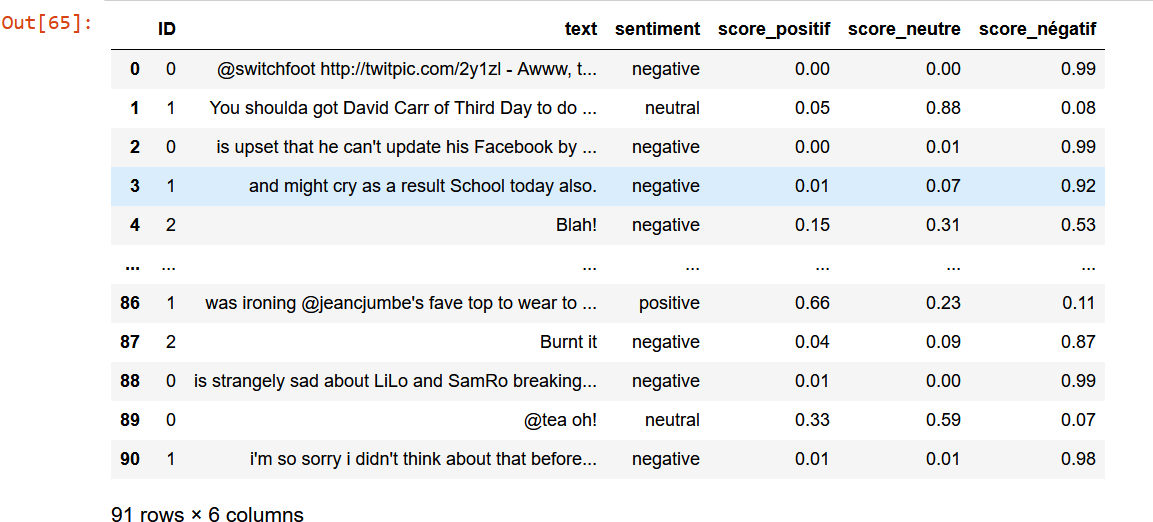

En utilisant l'API sur étagère d'Azure, nous avons pu prédire le sentiment d'un echantillon de texte avec les probalités d'appartenance au sentiment positif, négatif ou neutre.

# Approche “Modèle sur mesure simple” 

## Concepteur / Designer service Azure Machine Learning



 Nous avons réalisé cette étape directement sous Azure en plusieurs étapes...

1- Création du workplace Azure machine learning studio et utilisation de Designer Drag and Drop

2-Importation des échantillons construits (version avec texte brut, et version avec texte nettoyé) 

3- Construction des schémas du process pour chaque version



In [ ]:
# Création des 2 datasets à utiliser sous le concepteur d'Azure
# Randomly sample 20% of your dataframe
Data3 = dataset.sample(frac=0.2)

# Randomly sample 7 elements from your dataframe
#df_elements = df.sample(n=7)

#Preprocessing données pour concepteur Azure
text1= list(Data3['text']) 
sentiment1 = list(Data3['sentiment'])
import time
t = time.time()
processedtext1 = preprocess(text1)
print(f'Preprocessing effectué')
print(f'Temps utilisé: {round(time.time()-t)} secondes')

# Creation du dataframe à utiliser sous le concepteur Azure
tab = []
for text, pred in zip(processedtext1, sentiment1):
    tab.append((text,pred))
        
# Convert the list into a Pandas DataFrame.
Data4 = pd.DataFrame(tab, columns = ['text','sentiment'])

Les résultats avec l'approche sur mesure simple sont moins bons que ce que nous avons réalisé dans notre notebooK.Mais cela est principalement dû au fait que nous n'avons utilisé qu'une infine partie  de nos données sous Azure. Nous allons construire un modèle de regression logistique dans notre notebook avec le même echantillon afin de faire à nouveau la comparaison.

In [ ]:
### Séparation du jeu de données en jeu de test et jeu d'entraînement

X_train1, X_test1, y_train1, y_test1 = train_test_split(processedtext1, sentiment1,
                                                    test_size = 0.3, random_state = 0)
print(f'Séparation du jeu de données effectuée.')

In [ ]:
def model_Evaluate1(model):
    
    # Predict values for Test dataset
    y_pred1 = model.predict(X_test1)

    # Print the evaluation metrics for the dataset.
    print(classification_report(y_test1, y_pred1))
    
    # Compute and plot the Confusion matrix
    cf_matrix1 = confusion_matrix(y_test1, y_pred1)

    categories  = ['Negative','Positive']
    group_names = ['True Neg','False Pos', 'False Neg','True Pos']
    group_percentages = ['{0:.2%}'.format(value) for value in cf_matrix1.flatten() / np.sum(cf_matrix1)]

    labels = [f'{v1}\n{v2}' for v1, v2 in zip(group_names,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)

    sns.heatmap(cf_matrix1, annot = labels, cmap = 'Blues',fmt = '',
                xticklabels = categories, yticklabels = categories)

    plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
    plt.ylabel("Actual values"   , fontdict = {'size':14}, labelpad = 10)
    plt.title ("Confusion Matrix", fontdict = {'size':18}, pad = 20)

In [ ]:
### Vectorization TF-IDF
vectoriser = TfidfVectorizer(ngram_range=(1,2), max_features=500000)
vectoriser.fit(X_train1)
print(f'Vectorization TF-IDF effectuée.')
print('Nombre de mots features: ', len(vectoriser.get_feature_names_out()))

In [ ]:
# Application à nos jeux d'entraînement et de test
X_train1 = vectoriser.transform(X_train1)
X_test1  = vectoriser.transform(X_test1)
print(f'Jeux de données transformés')

In [ ]:
LRmodel1 = LogisticRegression(C = 2, max_iter = 1000, n_jobs=-1)
LRmodel1.fit(X_train1, y_train1)
model_Evaluate1(LRmodel1)

# Approche “Modèle sur mesure Avancé” 

Dans cette partie, nous allons utiliser des modèles de réseaux de neurones à plusieurs couches (deep learning) pour détecter le sentiment relatif à un tweet.

Comme nous l'avons constaté lors de la présentation des nuages de mots relatifs au sentiment positif et négatif, il y a des mots qui apparaissent à la fois dans les 2 nuages. Et cela se reflète dans la matrice de confusion des modèles classiques utilisés où la proportion des sentiments mal prédits reste tout de même importante.

Avec les RNN LSTM nous utiliserons des modèles séquentiels qui ont la capacité de reconnaître le sens des phrases ou des groupes de mots.

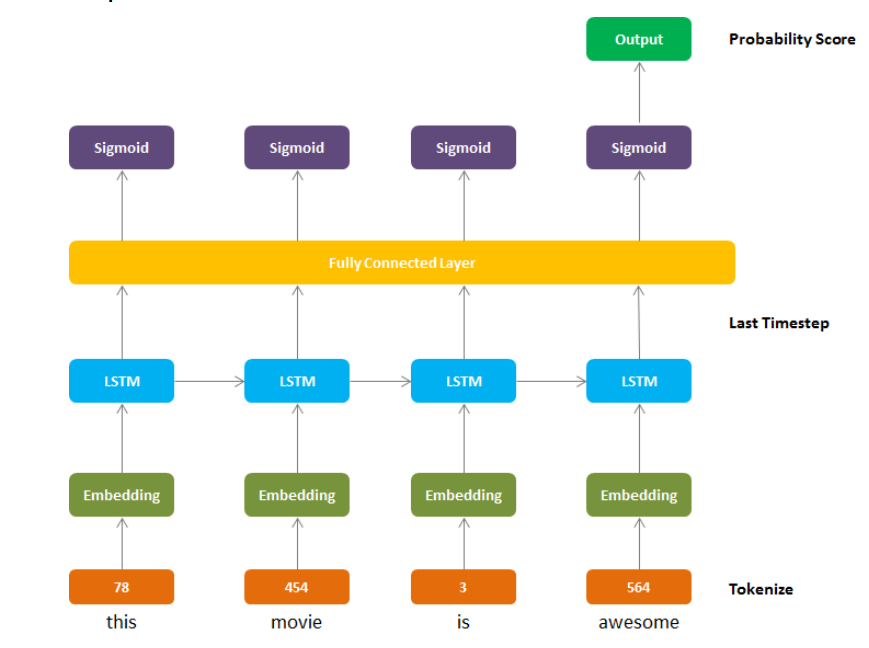

## RESEAU DE NEURONES LSTM

L'algorithme de réseau de neurones LSTM est un algorithme de réseau de neurones récurrents (ici la sortie est reutilisée comme entrée, d'où le terme récurrent) qui est constituée de portes d'entrées et de sorties permettant de stocker des mémoires temporaires (d'où le terme LSTM pour "long short term memory"). Il permet de ressortir le sens ou contexte d'une séquence de mots.

### Architecture de notre modèle

1) Embedding Layer : Il permettra de générer des vecteurs pour chaque séquence en entrée

2) Conv1D Layer : Transforme les données en features vector

3) LSTM : Il permet de ressortir le sens ou contexte d'une séquence de mots

4) Dense : Notre dernière couche pour la classification


### Word Embedding

Le Word Embedding est l'une des représentations les plus populaires du vocabulaire de documents. Il permet de capturer le contexte des mots, les similarités au niveau de la syntaxe et de la sémantique, les relations avec d'autres mots.

Entraîner son propre Embedding prend beaucoup de temps et de mémoire, notre analyse sera inspirée de la stratégie du Transfert Learning déjà réalisée lors de l'analyse des images (computer vision). Au lieu d'utiliser VGG16 comme dans l'exemple de prédiction des images, ici les embedding les plus populaires que nous utiliserons sont **GloVe & Word2Vec**. Nous allons tester les 2, afin de choisir celui qui nous donnera de meilleurs résultats.

Nous essayerons aussi une autre méthode nommée **BERT** en guise de perspective d'amélioration de notre modèle.

In [ ]:
#Importation des bibliothèques

import tensorflow as tf
import nltk 
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.preprocessing import LabelEncoder
print("Tensorflow Version",tf.__version__)

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU,SimpleRNN
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import BatchNormalization
#from tensorflow.keras.utils import np_utils
from sklearn import preprocessing, decomposition, model_selection, metrics, pipeline
from tensorflow.keras.layers import GlobalMaxPooling1D, Conv1D, MaxPooling1D, Flatten, Bidirectional, SpatialDropout1D
from tensorflow.keras.preprocessing import sequence, text
from tensorflow.keras.callbacks import EarlyStopping



#  Word Embedding Glove ****

In [ ]:
import tensorflow
from tensorflow.keras.datasets import mnist
from tensorflow.python.keras.utils import np_utils
from tensorflow.keras import Sequential
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D,Conv1D, Bidirectional, LSTM
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import SpatialDropout1D
from tensorflow.keras.callbacks import ModelCheckpoint



In [ ]:
import warnings
warnings.filterwarnings("ignore")
from keras.preprocessing.text import Tokenizer
from keras.preprocessing import sequence
import keras.backend as K
from keras.models import Sequential
from keras.layers import Dense,Embedding,LSTM
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [ ]:
Data_prepro['prepro_text'].apply(lambda x:len(str(x).split())).max()

In [ ]:
MAX_NB_WORDS = 100000
MAX_SEQUENCE_LENGTH = 52
train_data, test_data = train_test_split(Data_prepro, test_size=0.3,
                                         random_state=7) # Splits Dataset into Training and Testing set
print("Train Data size:", len(train_data))
print("Test Data size", len(test_data))

In [ ]:
train_data.head(10)

In [ ]:
labels = train_data.sentiment.unique().tolist()
labels

In [ ]:
#Tokenization
from keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_data.prepro_text)

word_index = tokenizer.word_index
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary Size :", vocab_size)

In [ ]:
from keras.preprocessing.sequence import pad_sequences

x_train = pad_sequences(tokenizer.texts_to_sequences(train_data.prepro_text),
                        maxlen = MAX_SEQUENCE_LENGTH)
x_test = pad_sequences(tokenizer.texts_to_sequences(test_data.prepro_text),
                       maxlen = MAX_SEQUENCE_LENGTH)

print("Training X Shape:",x_train.shape)
print("Testing X Shape:",x_test.shape)

In [ ]:
encoder = LabelEncoder()
encoder.fit(Data_prepro.sentiment.to_list())

y_train = encoder.transform(train_data.sentiment.to_list())
y_test = encoder.transform(test_data.sentiment.to_list())

y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

In [ ]:
#Construction du modèle
GLOVE_EMB = '../input/glove6b/glove.6B.300d.txt'
EMBEDDING_DIM = 300
LR = 1e-3
BATCH_SIZE = 1024
EPOCHS = 10
MODEL_PATH = '.../output/kaggle/working/best_model.hdf5'


In [ ]:
embeddings_index = {}
f = open(GLOVE_EMB)
for line in f:
    values = line.split()
    word = value = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()

print('Found %s word vectors.' %len(embeddings_index))

In [ ]:
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
         embedding_matrix[i] = embedding_vector

In [ ]:
embedding_layer = tf.keras.layers.Embedding(vocab_size,
                                          EMBEDDING_DIM,
                                          weights=[embedding_matrix],
                                          input_length=MAX_SEQUENCE_LENGTH,
                                          trainable=False)

In [ ]:
sequence_input = Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='int32')
embedding_sequences = embedding_layer(sequence_input)
x = SpatialDropout1D(0.2)(embedding_sequences)
x = Conv1D(64, 5, activation='relu')(x)
x = Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2))(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(sequence_input, outputs)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

model.compile(optimizer=Adam(learning_rate=LR), loss='binary_crossentropy',
              metrics=['accuracy'])
ReduceLROnPlateau = ReduceLROnPlateau(factor=0.1,
                                     min_lr = 0.01,
                                     monitor = 'val_loss',
                                     verbose = 1)

In [ ]:
#Verif 
print("Training on GPU...") if tf.test.is_gpu_available() else print("Training on CPU...")

In [ ]:
tf.config.experimental.list_physical_devices()

In [ ]:
#Train
history = model.fit(x_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS,
                    validation_data=(x_test, y_test), callbacks=[ReduceLROnPlateau])

In [ ]:
# Model evaluation
s, (at, al) = plt.subplots(2,1)
at.plot(history.history['accuracy'], c= 'b')
at.plot(history.history['val_accuracy'], c='r')
at.set_title('model accuracy')
at.set_ylabel('accuracy')
at.set_xlabel('epoch')
at.legend(['LSTM_train', 'LSTM_val'], loc='upper left')

al.plot(history.history['loss'], c='m')
al.plot(history.history['val_loss'], c='c')
al.set_title('model loss')
al.set_ylabel('loss')
al.set_xlabel('epoch')
al.legend(['train', 'val'], loc = 'upper left')

In [ ]:
def decode_sentiment(score):
    return "Positive" if score>0.5 else "Negative"


scores = model.predict(x_test, verbose=1, batch_size=10000)
y_pred_1d = [decode_sentiment(score) for score in scores]

##  Word Embedding Word2vec

In [ ]:
from gensim.models import KeyedVectors
filename = '../input/nlpword2vecembeddingspretrained/GoogleNews-vectors-negative300.bin'
w2v_pretrained_model = KeyedVectors.load_word2vec_format(filename, binary=True)

In [ ]:
embedding_matrix = np.zeros((vocab_size,300))
for word,i in tqdm(tokenizer.word_index.items()):
    try:
        embedding_value = w2v_pretrained_model[word]
        if embedding_value is not None:
            embedding_matrix[i] = embedding_value         
    except KeyError:
        embedding_matrix[i]=np.random.normal(0,np.sqrt(0.25),300)       

In [ ]:
  embedding_matrix.shape   

In [ ]:
embid_dim = 300
lstm_out = 128


model = keras.Sequential()
model.add(Embedding(vocab_size, embid_dim, input_length =X.shape[1], weights = [embedding_matrix] , trainable = False))
model.add(Bidirectional(LSTM(lstm_out, dropout=0.2)))
model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation = 'relu'))
model.add(Dense(2, activation = 'softmax'))
model.summary()

In [ ]:
batch_size = 128
model.compile(loss = 'categorical_crossentropy', optimizer='adam',metrics = ['accuracy'])
history = model.fit(X_train, Y_train, epochs = 5, batch_size=batch_size, verbose = 1, validation_data =(X_test, Y_test))

In [ ]:
def get_embed_mat(EMBEDDING_FILE, max_features=20000):
    # word vectors
    embeddings_index = dict(get_coefs(*o.rstrip().rsplit(' ')) for o in open(EMBEDDING_FILE, encoding='utf8'))
    print('Found %s word vectors.' % len(embeddings_index))

    # embedding matrix
    word_index = tokenizer.word_index
    num_words = min(max_features, len(word_index) + 1)
    all_embs = np.stack(embeddings_index.values()) #for random init
    embedding_matrix = np.random.normal(all_embs.mean(), all_embs.std(), 
                                        (num_words, embed_dim))
    for word, i in word_index.items():
        if i >= max_features:
            continue
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
    max_features = embedding_matrix.shape[0]
    
    return max_features, embedding_matrix
    
# embedding matrix
EMBEDDING_FILE = '../input/glove6b50dtxt/glove.6B.50d.txt'
embed_dim = 50 #word vector dim
max_features, embedding_matrix = get_embed_mat(EMBEDDING_FILE)


In [ ]:
# train the model
model = get_model(max_features, embed_dim, embedding_matrix)
model.fit(X_train, y_train, validation_data=(X_test, y_test),epochs=epochs, batch_size=batch_size, verbose=2)